# Gradient Boosting (1/2) — Gradient Boosting Step by Step (by hand)

**Idea:** start with a very simple guess (the average), then add small trees **one at a time**, where each new tree
learns the **mistakes (residuals)** that are still left. Add everything up and the guess gets better and better.

**In this notebook**
1. The data: a noisy curve $y = 3x^2 + \text{noise}$
2. Step 1: the first prediction is just the mean
3. Step 2: compute the residuals (errors)
4. Step 3: fit tree 1 on the residuals
5. Step 4: prediction 2 = mean + tree 1, and new residuals
6. Step 5: tree 2, prediction 3
7. Put it in a loop: a `gradient_boost` function
8. Watching the model grow: 1, 2, 3, 5, 10, 50 trees
9. The learning rate (shrinkage)
10. Train vs test error: too many trees can overfit
11. Check: our hand-made model vs scikit-learn's `GradientBoostingRegressor`

> 📖 Theory: [`theory.md`](theory.md) §1–§5 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. The data

100 random points with $x$ between −0.5 and 0.5 and $y = 3x^2$ plus a little noise. The true shape is a **U-curve**,
something a single straight line or a single small tree cannot capture well.

> ✍️ **Core code: learn this.** Create the data (fixed seed so everyone gets the same numbers).

In [2]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5                 # shape (100, 1): sklearn wants a 2-D X
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

df = pd.DataFrame({'X': X[:, 0], 'y': y})
df.head()

,X,y
0,-0.1255,0.0516
1,0.4507,0.5945
2,0.2320,0.1661
3,0.0987,-0.0702
4,-0.3440,0.3440


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

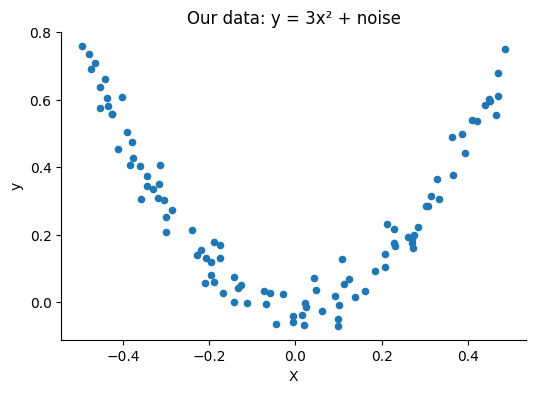

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['y'], s=20)
plt.title('Our data: y = 3x² + noise')
plt.xlabel('X'); plt.ylabel('y')
plt.show()

## 2. Step 1: the first prediction is the mean

Gradient boosting for regression (with squared error) always starts from **one constant number** for every row:
the **mean of y**. It is the best single constant under squared error. We **compute** it instead of typing it in.

> ✍️ **Core code: learn this.** Prediction 1 = the mean of y, the same for every row.

In [4]:
f0 = y.mean()                      # the starting guess
df['pred1'] = f0
print(f"Mean of y (prediction 1) = {f0:.6f}")
print(f"MSE of prediction 1      = {mean_squared_error(y, df['pred1']):.5f}")

Mean of y (prediction 1) = 0.265458
MSE of prediction 1      = 0.05570


In the original version of this notebook this number was hard-coded as `0.265458`; computing it with `y.mean()` gives the same value
and never goes out of date if the data changes.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

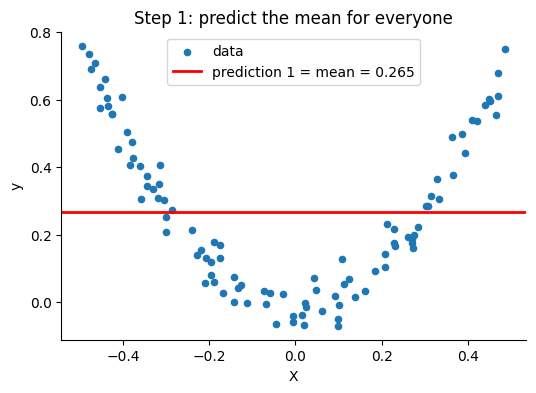

In [5]:
X_plot = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)    # a fine grid for drawing smooth lines
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['y'], s=20, label='data')
plt.axhline(f0, color='red', lw=2, label=f'prediction 1 = mean = {f0:.3f}')
plt.title('Step 1: predict the mean for everyone')
plt.xlabel('X'); plt.ylabel('y'); plt.legend()
plt.show()

A flat line: too high in the middle, too low at both ends. Those errors are what the next tree will learn.

## 3. Step 2: compute the residuals

$$\text{residual} = y - \text{prediction}$$

- positive residual → we predicted **too low** (we need to go **up**)
- negative residual → we predicted **too high** (we need to go **down**)

For squared error, the residual is exactly the **negative gradient** of the loss. That is where the name
*gradient* boosting comes from (theory §2).

> ✍️ **Core code: learn this.** Residuals = actual − predicted.

In [6]:
df['res1'] = df['y'] - df['pred1']
df.head()

,X,y,pred1,res1
0,-0.1255,0.0516,0.2655,-0.2139
1,0.4507,0.5945,0.2655,0.3290
2,0.2320,0.1661,0.2655,-0.0994
3,0.0987,-0.0702,0.2655,-0.3356
4,-0.3440,0.3440,0.2655,0.0785


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

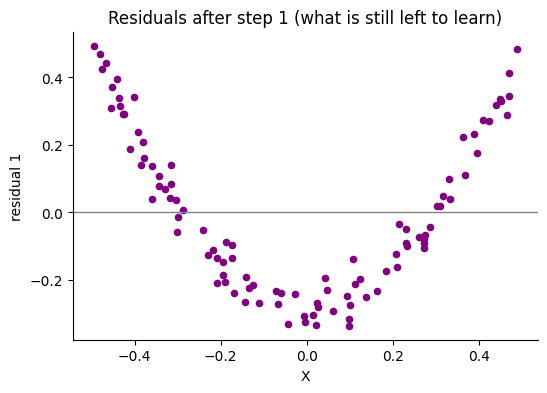

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['res1'], s=20, color='purple')
plt.axhline(0, color='gray', lw=1)
plt.title('Residuals after step 1 (what is still left to learn)')
plt.xlabel('X'); plt.ylabel('residual 1')
plt.show()

The residuals themselves form a U-shape: the pattern the mean missed. Tree 1 will try to learn it.

## 4. Step 3: fit tree 1 on the residuals

The key trick: **the target of the tree is the residual, not y.** We use a small tree (`max_leaf_nodes=8`), so it can
only give 8 different output values: a rough staircase.

> ✍️ **Core code: learn this.** Fit a small regression tree on X → residual 1.

In [8]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
tree1.fit(X, df['res1'])
print('Leaves:', tree1.get_n_leaves(), '| depth:', tree1.get_depth())

Leaves: 8 | depth: 5


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

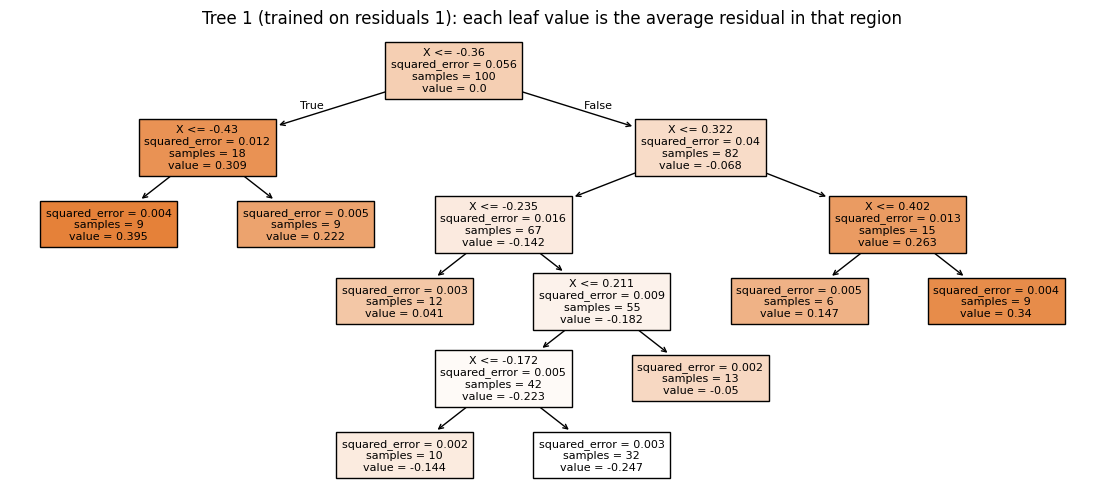

In [9]:
plt.figure(figsize=(14, 6))
plot_tree(tree1, filled=True, feature_names=['X'], precision=3, fontsize=8)
plt.title('Tree 1 (trained on residuals 1): each leaf value is the average residual in that region')
plt.show()

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

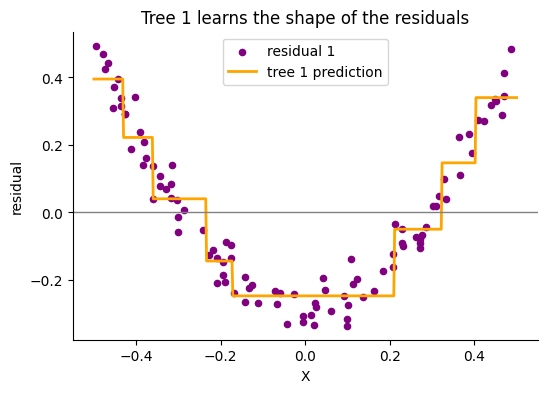

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['res1'], s=20, color='purple', label='residual 1')
plt.plot(X_plot[:, 0], tree1.predict(X_plot), color='orange', lw=2, label='tree 1 prediction')
plt.axhline(0, color='gray', lw=1)
plt.title('Tree 1 learns the shape of the residuals')
plt.xlabel('X'); plt.ylabel('residual'); plt.legend()
plt.show()

## 5. Step 4: prediction 2 = mean + tree 1

Add the tree's correction to the starting guess. For now we use a **learning rate of 1** (add the full correction),
exactly like the original notebook. Section 9 shows why a smaller learning rate is usually better.

> ✍️ **Core code: learn this.** New prediction = old prediction + tree's correction; then new residuals.

In [11]:
df['pred2'] = df['pred1'] + tree1.predict(X)
df['res2']  = df['y'] - df['pred2']
df[['X', 'y', 'pred1', 'res1', 'pred2', 'res2']].head()

,X,y,pred1,res1,pred2,res2
0,-0.1255,0.0516,0.2655,-0.2139,0.0183,0.0333
1,0.4507,0.5945,0.2655,0.3290,0.6059,-0.0114
2,0.2320,0.1661,0.2655,-0.0994,0.2158,-0.0497
3,0.0987,-0.0702,0.2655,-0.3356,0.0183,-0.0885
4,-0.3440,0.3440,0.2655,0.0785,0.3060,0.0380


In [12]:
print(f"MSE after step 1 (mean only)   : {mean_squared_error(y, df['pred1']):.5f}")
print(f"MSE after step 2 (mean + tree1): {mean_squared_error(y, df['pred2']):.5f}")

MSE after step 1 (mean only)   : 0.05570
MSE after step 2 (mean + tree1): 0.00332


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

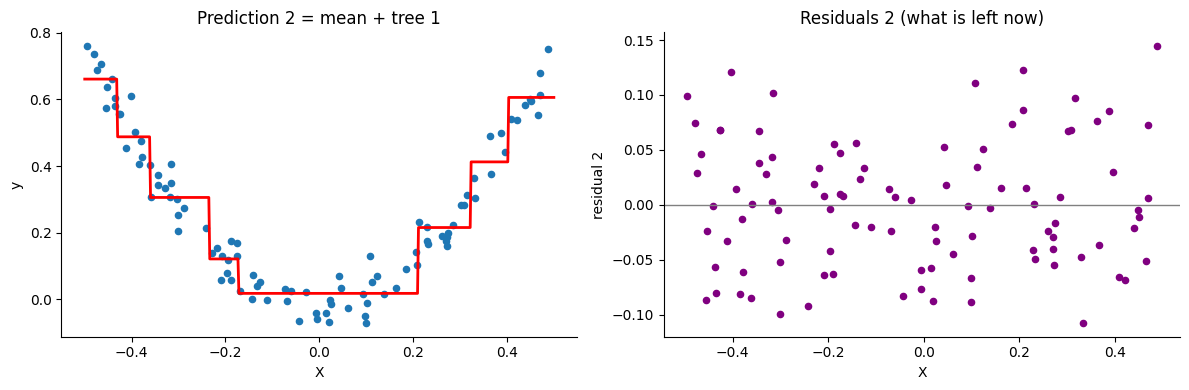

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(df['X'], df['y'], s=20)
plt.plot(X_plot[:, 0], f0 + tree1.predict(X_plot), color='red', lw=2)
plt.title('Prediction 2 = mean + tree 1'); plt.xlabel('X'); plt.ylabel('y')
plt.subplot(122)
plt.scatter(df['X'], df['res2'], s=20, color='purple')
plt.axhline(0, color='gray', lw=1)
plt.title('Residuals 2 (what is left now)'); plt.xlabel('X'); plt.ylabel('residual 2')
plt.tight_layout(); plt.show()

The red staircase already follows the U-curve. The residuals are now much smaller and no longer show an obvious U;
what is left is mostly small leftovers near the step edges and noise.

## 6. Step 5: tree 2 on residuals 2, prediction 3

Same move again: a **new** tree learns what is **still** wrong.

> ✍️ **Core code: learn this.** Repeat: fit tree 2 on residual 2, add it.

In [14]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
tree2.fit(X, df['res2'])

df['pred3'] = df['pred2'] + tree2.predict(X)
df['res3']  = df['y'] - df['pred3']
df[['y', 'pred1', 'pred2', 'pred3', 'res1', 'res2', 'res3']].head()

,y,pred1,pred2,pred3,res1,res2,res3
0,0.0516,0.2655,0.0183,0.0143,-0.2139,0.0333,0.0373
1,0.5945,0.2655,0.6059,0.5975,0.3290,-0.0114,-0.0030
2,0.1661,0.2655,0.2158,0.2074,-0.0994,-0.0497,-0.0414
3,-0.0702,0.2655,0.0183,-0.0198,-0.3356,-0.0885,-0.0504
4,0.3440,0.2655,0.3060,0.3020,0.0785,0.0380,0.0420


In [15]:
summary = pd.DataFrame({
    'model': ['mean', 'mean + tree1', 'mean + tree1 + tree2'],
    'train MSE': [mean_squared_error(y, df[c]) for c in ['pred1', 'pred2', 'pred3']],
    'mean |residual|': [df[c].abs().mean() for c in ['res1', 'res2', 'res3']],
})
summary.style.format({'train MSE': '{:.5f}', 'mean |residual|': '{:.4f}'})

,model,train MSE,mean |residual|
0,mean,0.05570,0.2040
1,mean + tree1,0.00332,0.0472
2,mean + tree1 + tree2,0.00213,0.0378


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

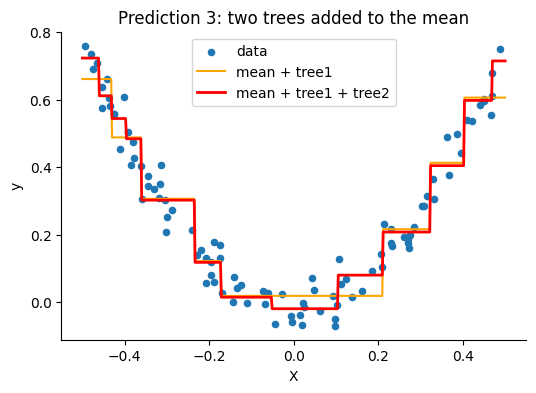

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['y'], s=20, label='data')
plt.plot(X_plot[:, 0], f0 + tree1.predict(X_plot), color='orange', lw=1.5, label='mean + tree1')
plt.plot(X_plot[:, 0], f0 + tree1.predict(X_plot) + tree2.predict(X_plot), color='red', lw=2, label='mean + tree1 + tree2')
plt.title('Prediction 3: two trees added to the mean'); plt.xlabel('X'); plt.ylabel('y'); plt.legend()
plt.show()

With two trees the staircase has **more, smaller steps**: tree 2 fine-tunes the regions where tree 1 was off.

## 7. Put it in a loop: a `gradient_boost` function

The steps above are always the same, so we write them once:

$$F_0 = \bar y, \qquad r_m = y - F_{m-1}(x), \qquad F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where $h_m$ is tree number $m$ (trained on $r_m$) and $\eta$ is the **learning rate**.

> The original notebook used a *recursive* function. It worked for `lr=1`, but it had three problems we fix here:
> it started from 0 instead of the mean, it computed residuals **without** the learning rate (so for `lr < 1` the
> trees learned the wrong residuals), and it used a mutable default list `regs=[]` that keeps old trees between calls.
> A simple `for` loop is clearer and does the same job.

> ✍️ **Core code: learn this.** The whole algorithm in about 10 lines.

In [17]:
def gradient_boost(X, y, n_trees, lr, max_leaf_nodes=8):
    """Gradient boosting for regression with squared error, written by hand."""
    f0 = y.mean()                        # step 1: start from the mean
    F = np.full(len(y), f0)              # current prediction for every training row
    trees = []
    for m in range(n_trees):
        residuals = y - F                # step 2: what is still wrong (= negative gradient)
        tree = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=42)
        tree.fit(X, residuals)           # step 3: a small tree learns the residuals
        F = F + lr * tree.predict(X)     # step 4: add a *scaled* correction
        trees.append(tree)
    return f0, trees

def gb_predict(X, f0, trees, lr):
    """Prediction = mean + lr * (sum of all trees)."""
    return f0 + lr * sum(tree.predict(X) for tree in trees)

In [18]:
f0_, trees = gradient_boost(X, y, n_trees=2, lr=1.0)
same = np.allclose(gb_predict(X, f0_, trees, lr=1.0), df['pred3'])
print('Function with 2 trees and lr=1 gives the same predictions as our manual steps:', same)

Function with 2 trees and lr=1 gives the same predictions as our manual steps: True


## 8. Watching the model grow (learning rate = 1)

Below: the ensemble after 1, 2, 3, 5, 10 and 50 trees. In each panel, the **red line** is the model's prediction.

In [19]:
lr = 1.0
f0_, trees_lr1 = gradient_boost(X, y, n_trees=50, lr=lr)
for k in [1, 2, 3, 5, 10, 50]:
    mse = mean_squared_error(y, gb_predict(X, f0_, trees_lr1[:k], lr))
    print(f"{k:>2} trees -> train MSE = {mse:.5f}")

 1 trees -> train MSE = 0.00332
 2 trees -> train MSE = 0.00213
 3 trees -> train MSE = 0.00158
 5 trees -> train MSE = 0.00079
10 trees -> train MSE = 0.00027
50 trees -> train MSE = 0.00000


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

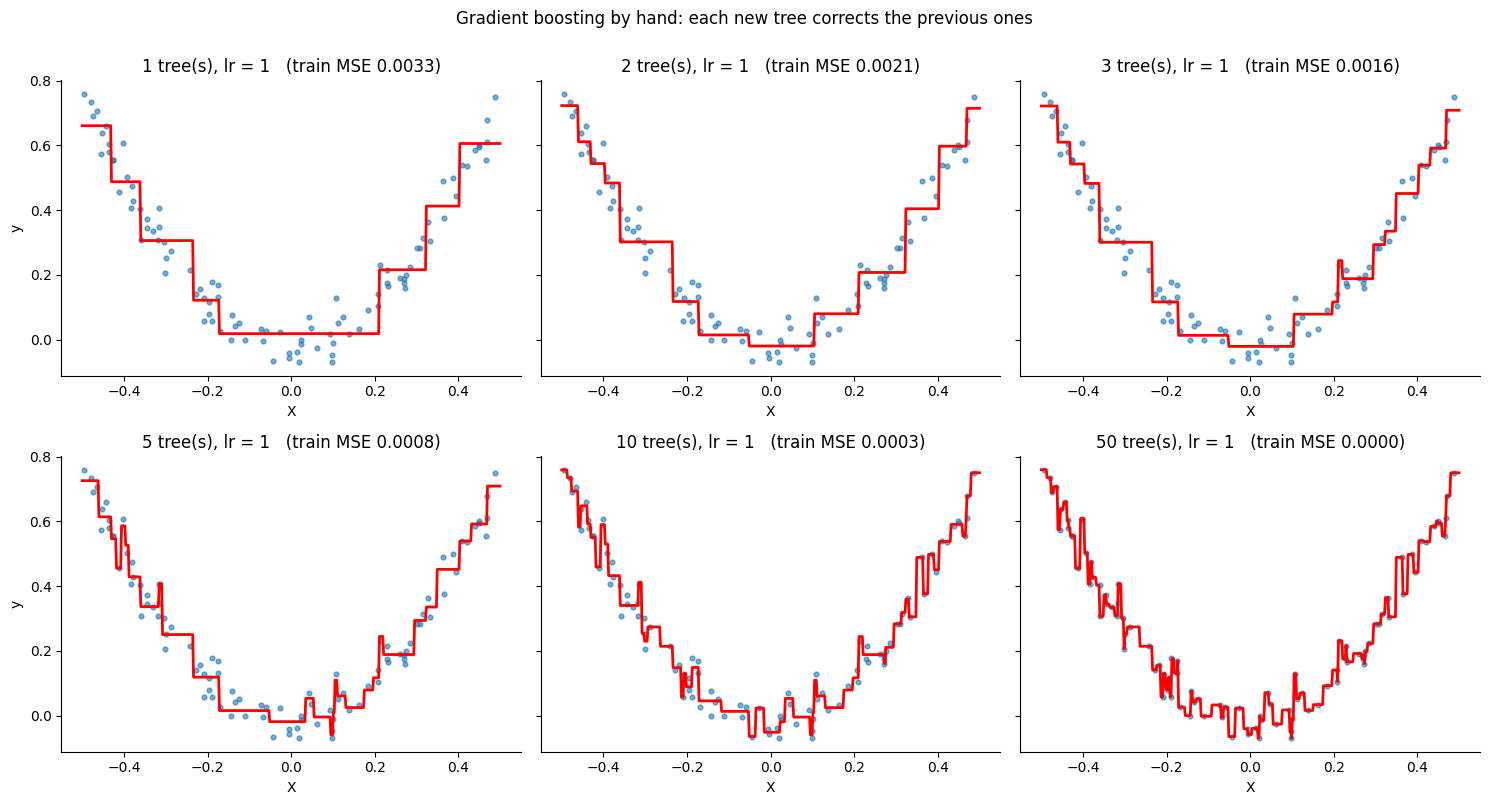

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, k in zip(axes.ravel(), [1, 2, 3, 5, 10, 50]):
    ax.scatter(X[:, 0], y, s=12, alpha=0.6)
    ax.plot(X_plot[:, 0], gb_predict(X_plot, f0_, trees_lr1[:k], lr), color='red', lw=2)
    mse = mean_squared_error(y, gb_predict(X, f0_, trees_lr1[:k], lr))
    ax.set_title(f'{k} tree(s), lr = 1   (train MSE {mse:.4f})')
    ax.set_xlabel('X')
axes[0, 0].set_ylabel('y'); axes[1, 0].set_ylabel('y')
plt.suptitle('Gradient boosting by hand: each new tree corrects the previous ones', y=1.0)
plt.tight_layout(); plt.show()

- With **1–3 trees** the model quickly captures the U-shape.
- With **50 trees and lr = 1** the line becomes very jagged: it jumps up and down to hit individual noisy points.
  The training error is almost zero: this is **overfitting**. The noise is not a pattern worth learning.

## 9. The learning rate (shrinkage)

Instead of adding the full correction of each tree, we add only a **fraction** of it: $F_m = F_{m-1} + \eta \cdot h_m$.
- big $\eta$ (e.g. 1): learns fast, but each tree can over-correct and chase noise;
- small $\eta$ (e.g. 0.1): learns slowly and smoothly, so it **needs more trees**.

Think of walking down a hill in the fog: small careful steps take longer but you are less likely to overshoot.

> ✍️ **Core code: learn this.** Same function, different learning rates.

In [21]:
rates = [1.0, 0.3, 0.1]
models = {lr: gradient_boost(X, y, n_trees=50, lr=lr) for lr in rates}

rows = []
for k in [1, 3, 10, 50]:
    row = {'trees': k}
    for lr, (f0_lr, trees_lr) in models.items():
        row[f'lr={lr}'] = mean_squared_error(y, gb_predict(X, f0_lr, trees_lr[:k], lr))
    rows.append(row)
print('Train MSE')
pd.DataFrame(rows).set_index('trees').style.format('{:.5f}')

Train MSE


,lr=1.0,lr=0.3,lr=0.1
trees,,,
1,0.00332,0.02898,0.04575
3,0.00158,0.00832,0.03103
10,0.00027,0.00087,0.00850
50,0.00000,0.00007,0.00057


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

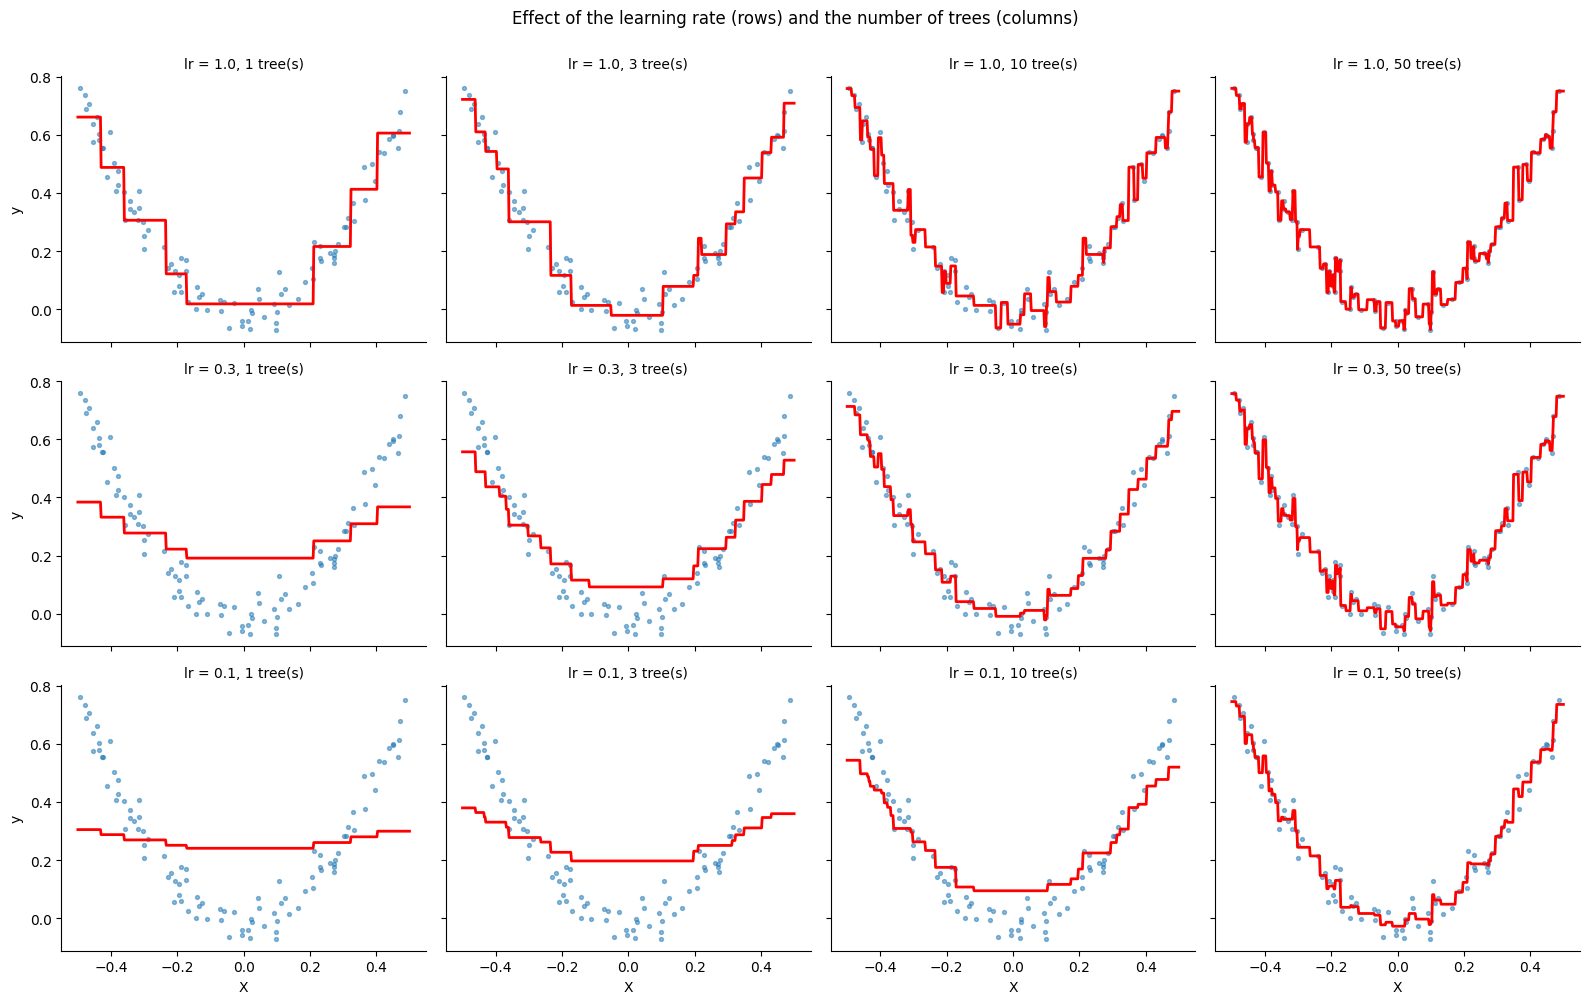

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for i, lr in enumerate(rates):
    f0_lr, trees_lr = models[lr]
    for j, k in enumerate([1, 3, 10, 50]):
        ax = axes[i, j]
        ax.scatter(X[:, 0], y, s=8, alpha=0.5)
        ax.plot(X_plot[:, 0], gb_predict(X_plot, f0_lr, trees_lr[:k], lr), color='red', lw=2)
        ax.set_title(f'lr = {lr}, {k} tree(s)', fontsize=10)
        if j == 0: ax.set_ylabel('y')
        if i == 2: ax.set_xlabel('X')
plt.suptitle('Effect of the learning rate (rows) and the number of trees (columns)', y=1.0)
plt.tight_layout(); plt.show()

- **lr = 1 (top row):** a good fit after 1–3 trees, but by 10 and 50 trees the line is jagged: it chases single noisy points.
- **lr = 0.1 (bottom row):** after 1 tree the line has barely moved from the mean, and after 10 trees it is still too flat.
  After 50 trees it follows the curve, with fewer wild jumps than lr = 1 (though it is starting to chase a few points too).
- **lr = 0.3** sits in between.
- A smaller learning rate needs **more trees**. Is it actually better on new data? Let's check.

## 10. Train vs test error: too many trees can overfit

We create a **fresh test set** from the same curve (a different seed) and track both errors as trees are added.

In [23]:
rng = np.random.RandomState(7)
X_test = rng.rand(500, 1) - 0.5
y_test = 3 * X_test[:, 0]**2 + 0.05 * rng.randn(500)

n_max = 200
curves = {}
for lr in rates:
    f0_lr, trees_lr = gradient_boost(X, y, n_trees=n_max, lr=lr)
    F_tr, F_te = np.full(len(y), f0_lr), np.full(len(y_test), f0_lr)
    tr, te = [], []
    for tree in trees_lr:                       # add trees one by one and record both errors
        F_tr += lr * tree.predict(X);  F_te += lr * tree.predict(X_test)
        tr.append(mean_squared_error(y, F_tr)); te.append(mean_squared_error(y_test, F_te))
    curves[lr] = (np.array(tr), np.array(te))

best = pd.DataFrame({
    'learning rate': rates,
    'best #trees (test)': [curves[lr][1].argmin() + 1 for lr in rates],
    'best test MSE': [curves[lr][1].min() for lr in rates],
    'test MSE at 200 trees': [curves[lr][1][-1] for lr in rates],
    'train MSE at 200 trees': [curves[lr][0][-1] for lr in rates],
})
best.style.format({'best test MSE': '{:.4f}', 'test MSE at 200 trees': '{:.4f}', 'train MSE at 200 trees': '{:.5f}', 'learning rate': '{:.1f}'})

,learning rate,best #trees (test),best test MSE,test MSE at 200 trees,train MSE at 200 trees
0,1.0,4,0.0037,0.0041,0.00000
1,0.3,11,0.0029,0.0041,0.00000
2,0.1,33,0.0029,0.0038,0.00004


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

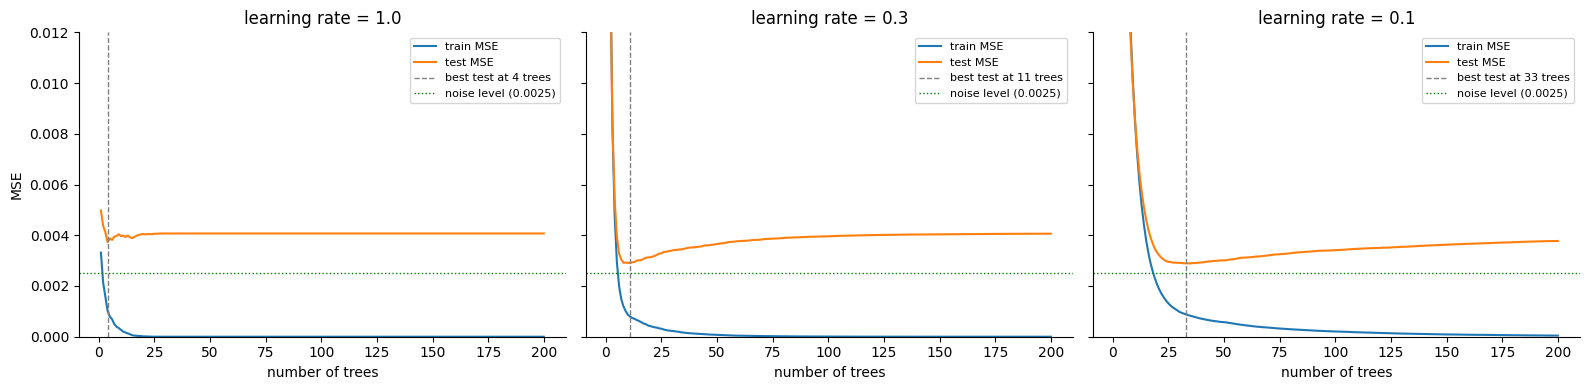

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, lr in zip(axes, rates):
    tr, te = curves[lr]
    ax.plot(range(1, n_max + 1), tr, label='train MSE')
    ax.plot(range(1, n_max + 1), te, label='test MSE')
    ax.axvline(te.argmin() + 1, color='gray', ls='--', lw=1, label=f'best test at {te.argmin() + 1} trees')
    ax.axhline(0.05**2, color='green', ls=':', lw=1, label='noise level (0.0025)')
    ax.set_ylim(0, 0.012); ax.set_title(f'learning rate = {lr}')
    ax.set_xlabel('number of trees'); ax.legend(fontsize=8)
axes[0].set_ylabel('MSE')
plt.tight_layout(); plt.show()

What to notice:
- The **train** error keeps falling towards 0 as trees are added (the model memorises the training points).
- The **test** error falls, reaches a minimum, then **rises a little**: that is overfitting.
- The dotted green line is the noise level ($0.05^2 = 0.0025$): no model can be expected to beat it on new data.
- With lr = 1 the best test MSE is 0.0037 after only 4 trees. With lr = 0.3 and 0.1 the best is lower (0.0029),
  reached later (11 and 33 trees). A smaller learning rate needs more trees but gave a **better** best model here.
- After 200 trees all three have overfitted (test MSE 0.0038–0.0041), so the number of trees still matters.

This is why in practice we pick a smallish learning rate and choose the number of trees with validation data or
**early stopping** (next notebook).

## 11. Check: our hand-made model vs scikit-learn

`GradientBoostingRegressor` does exactly what we did (for squared error):
start from the mean (`init` = a `DummyRegressor` that predicts the mean), fit trees on residuals, add `learning_rate × tree`.
Let's compare with 50 trees and `learning_rate=0.1`.

> ✍️ **Core code: learn this.** The same model in one line of scikit-learn.

In [25]:
k, lr = 50, 0.1
f0_hand, trees_hand = gradient_boost(X, y, n_trees=k, lr=lr)
pred_hand = gb_predict(X_test, f0_hand, trees_hand, lr)

gbr_default = GradientBoostingRegressor(n_estimators=k, learning_rate=lr, max_leaf_nodes=8,
                                        random_state=42).fit(X, y)
print(f"sklearn starting value (init_): {gbr_default.init_.constant_.ravel()[0]:.6f} | our mean: {f0_hand:.6f}")
print(f"max |difference|, sklearn default max_depth=3: {np.abs(gbr_default.predict(X_test) - pred_hand).max():.5f}")

sklearn starting value (init_): 0.265458 | our mean: 0.265458
max |difference|, sklearn default max_depth=3: 0.01518


The starting value matches, but the predictions are **not** identical. Why? `GradientBoostingRegressor` has
`max_depth=3` **by default**, and in this scikit-learn version it still applies even when we set `max_leaf_nodes=8`.
Our hand-made trees have `max_depth=None`, so they can grow deeper (still 8 leaves). Let's look at the depths:

In [26]:
print('depth of our tree 1      :', trees_hand[0].get_depth())
print('depth of sklearn tree 1  :', gbr_default.estimators_[0, 0].get_depth())

depth of our tree 1      : 5
depth of sklearn tree 1  : 3


Now remove the depth limit (`max_depth=None`) so both models build the same trees:

In [27]:
gbr = GradientBoostingRegressor(n_estimators=k, learning_rate=lr, max_leaf_nodes=8, max_depth=None,
                                random_state=42).fit(X, y)
diff = np.abs(gbr.predict(X_test) - pred_hand).max()
print('max |difference| with max_depth=None:', diff)
print(f"test MSE  by hand: {mean_squared_error(y_test, pred_hand):.6f} | sklearn: {mean_squared_error(y_test, gbr.predict(X_test)):.6f}")

max |difference| with max_depth=None: 2.220446049250313e-16
test MSE  by hand: 0.003009 | sklearn: 0.003009


Now they agree (any difference is at the level of floating-point rounding). Our ten-line function **is**
gradient boosting for regression.

Small details we did not need here: scikit-learn grows trees on the residuals exactly like us for squared error; for
other losses (absolute error, Huber, log-loss) it also recomputes the leaf values with a loss-specific formula.

## Key takeaways

- Gradient boosting starts with the **mean**, then each new small tree is trained on the **residuals** (what is still wrong).
- Prediction = mean + learning rate × (tree 1 + tree 2 + … ).
- For squared error, the residual is the **negative gradient** of the loss, hence the name.
- A big learning rate fits fast but overfits quickly; a small one needs **more trees** but is smoother and more forgiving.
- Training error always goes down with more trees; **test error** has a minimum, so the number of trees must be chosen with validation data.
- Our hand-made version matched `GradientBoostingRegressor` once we set `max_depth=None` (its default `max_depth=3` still limits the trees).

## 🧠 Quick check

<details><summary>1. What is the very first prediction in gradient boosting for regression (squared error)?</summary>
The mean of y, the same number for every row.</details>

<details><summary>2. What is the target (the "y") of tree number 3?</summary>
The residuals left after the mean + tree 1 + tree 2 (scaled by the learning rate): <code>y − F₂(x)</code>.</details>

<details><summary>3. If you lower the learning rate from 1.0 to 0.1, what else should you usually change?</summary>
Increase the number of trees, because each tree now adds only 10% of its correction.</details>

<details><summary>4. Training MSE keeps going down as we add trees. Does that mean more trees is always better?</summary>
No. Test error reaches a minimum and then rises (overfitting), especially with a large learning rate. Choose the number of trees with validation data or early stopping.</details>

➡️ **Next:** [`02-gradient-boosting-in-sklearn.ipynb`](02-gradient-boosting-in-sklearn.ipynb): the scikit-learn classes on real-sized data, staged predictions, early stopping, tuning and classification.